# 🖼️ 00 · 图像基础与图像处理

> 目标：把「一张图 = 一个数值矩阵」这个事实吃透，手写灰度化 / 直方图均衡化 / 卷积滤波 / 阈值分割 / 几何变换，
> 这些是 CV 面试**必被追问的基础操作**——面试官常让你「当场写一个高斯模糊 / Otsu / 双线性插值」。

> 🧩 **生活化类比**：像素就是乐高拼图的单颗颗粒，分辨率决定了拼图颗粒数；图像处理就是在拼图上做「整体调色、磨皮、描边、缩放」。


## 1. 一张图像 = 矩阵（像素 / 分辨率 / 通道 / 位深）

| 概念 | 定义 | 例子 |
|------|------|------|
| 像素 pixel | 图像最小单元，一个数值（灰度）或一组数值（彩色） | 灰度 128 |
| 分辨率 | 像素总数 $H \times W$ | 1080p = $1920 \times 1080$ |
| 通道 channel | 每个像素有几个数值 | RGB=3、灰度=1、RGBA=4 |
| 位深 bit depth | 每个通道用几个 bit 存 | 8bit（0–255）、16bit、float32 |
| 数据形状 | 灰度 $(H,W)$；彩色 $(H,W,C)$ | NumPy 里就是 ndarray |

**关键心智**：深度学习之前的传统 CV 全部是「矩阵运算」——滤波 = 卷积、找边 = 梯度、分割 = 阈值/聚类。
所以这一讲把 NumPy 图像操作练熟，后面 CNN / 检测 / 分割全都是在它之上堆结构。


合成图形状: (256, 256)  dtype: float32
灰度范围: [0.050, 1.000]


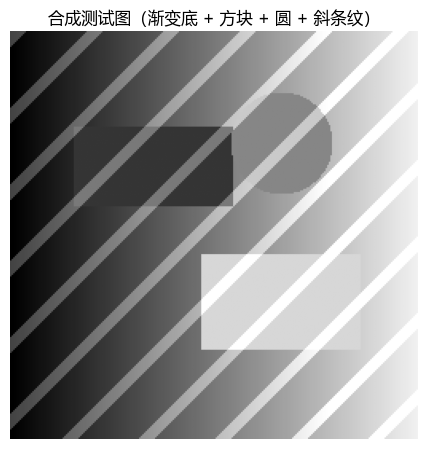

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
rng = np.random.default_rng(42)

# ---------- 工具：合成测试图（不依赖外部图片，保证可复现） ----------
def make_test_image(size=256):
    # 灰度渐变底 + 暗/亮方块 + 圆 + 斜条纹，覆盖多种灰度分布
    yy, xx = np.mgrid[0:size, 0:size].astype(np.float32)
    img = (xx / size) * 0.9 + 0.05                      # 横向渐变底
    img[60:110, 40:140] = 0.25                          # 暗方块
    img[140:200, 120:220] = 0.85                        # 亮方块
    mask = (xx - 170) ** 2 + (yy - 70) ** 2 < 32 ** 2
    img[mask] = 0.55                                    # 圆
    stripe = (xx + yy) % 48 < 10
    img[stripe] = np.clip(img[stripe] + 0.25, 0, 1)     # 斜条纹
    return np.clip(img, 0, 1)

def show_h(imgs, titles, figsize=(12, 3.6), cmap='gray'):
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    axes = np.atleast_1d(axes)
    for ax, im, t in zip(axes, imgs, titles):
        ax.imshow(im, cmap=cmap); ax.set_title(t); ax.axis('off')
    plt.tight_layout(); plt.show()

img = make_test_image()
print('合成图形状:', img.shape, ' dtype:', img.dtype)
print('灰度范围: [%.3f, %.3f]' % (img.min(), img.max()))
show_h([img], ['合成测试图（渐变底 + 方块 + 圆 + 斜条纹）'], figsize=(4.6, 4.6))


## 2. 像素级操作：亮度 / 负片 / 翻转 / ROI

- **亮度**：`g + c`，注意 clip 到合法区间（浮点域 [0,1] 或整数域 [0,255]）
- **负片**：`255 - g`（浮点域 `1 - g`），把暗变亮亮变暗
- **翻转 / 镜像**：`g[:, ::-1]`（水平）、`g[::-1]`（垂直）
- **ROI 裁剪**：NumPy 切片 `g[y0:y1, x0:x1]`

> ⚠️ **最经典的坑**：uint8 溢出回绕。`np.uint8(250) + np.uint8(20) = 14`（模 256），
> 所以图像代码里要么先转 float 再运算最后 clip，要么用 int16 中间量。


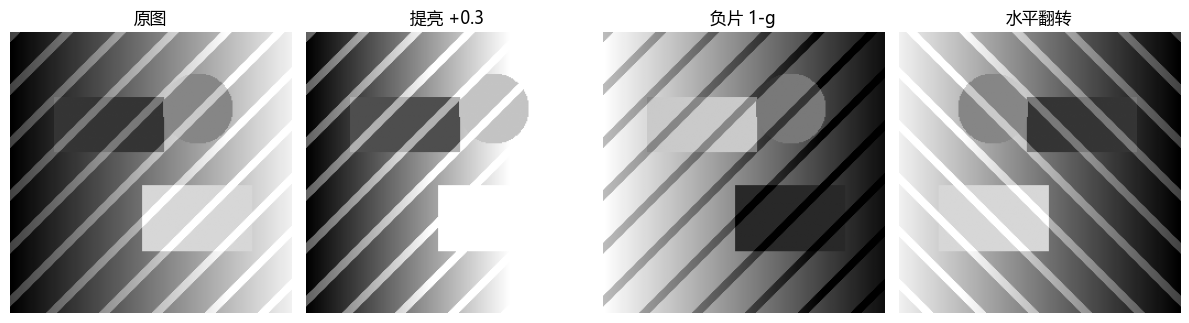

像素 (100,100) 原值=127，+30 后显示=157（该像素在暗方块，未溢出 -> 正确写法仍是先转 float）
受控演示：np.uint8(250) + np.uint8(30) = 24 （250+30=280 超出 255，回绕为 24）
结论：uint8 域加减会回绕，必须先转 float/int16 再 clip


C:\Users\24260\AppData\Local\Temp\ipykernel_29496\4177174425.py:14: RuntimeWarning: overflow encountered in scalar add
  print('受控演示：np.uint8(250) + np.uint8(30) =', int(a + b), '（250+30=280 超出 255，回绕为 24）')
C:\Users\24260\AppData\Local\Temp\ipykernel_29496\4177174425.py:15: RuntimeWarning: overflow encountered in scalar add
  assert int(a + b) == 24  # 溢出回绕：280 % 256 = 24


In [2]:
# ---------- 实验 1：像素级操作 ----------
bright = np.clip(img + 0.3, 0, 1)      # 提亮
neg = 1.0 - img                        # 负片
flip = img[:, ::-1]                    # 水平翻转
roi = img[60:110, 40:140]              # ROI 裁剪（暗方块）
show_h([img, bright, neg, flip], ['原图', '提亮 +0.3', '负片 1-g', '水平翻转'])

# uint8 溢出回绕演示（面试常问）
u8 = (img * 255).astype(np.uint8)
wrapped = (u8.astype(np.int16) + 30).astype(np.uint8)   # 先加再截断，模拟溢出
print('像素 (100,100) 原值=%d，+30 后显示=%d（该像素在暗方块，未溢出 -> 正确写法仍是先转 float）' %
      (int(u8[100, 100]), int(wrapped[100, 100])))
a, b = np.uint8(250), np.uint8(30)
print('受控演示：np.uint8(250) + np.uint8(30) =', int(a + b), '（250+30=280 超出 255，回绕为 24）')
assert int(a + b) == 24  # 溢出回绕：280 % 256 = 24
print('结论：uint8 域加减会回绕，必须先转 float/int16 再 clip')


## 3. 灰度化：为什么用 0.299/0.587/0.114 加权

把 RGB 三通道压成一通道灰度，常见三种：

| 方法 | 公式 | 特点 |
|------|------|------|
| 平均法 | $(R+G+B)/3$ | 简单，但人眼对绿色最敏感，平均法偏亮 |
| **Luma 加权**（推荐） | $0.299R + 0.587G + 0.114B$ | 符合人眼感知（BT.601 标准） |
| 取 V 通道 | $\\max(R,G,B)$ | 亮度最高的通道，偏亮 |

同样是灰色，`Luma` 与 `平均` 可差十几个灰度级——面试问「灰度化有哪些做法，用哪个」要能答出加权原因：
**人眼对绿光最敏感（视锥细胞分布），所以绿色权重最大。**


平均法 vs Luma 最大灰度差: 0.169 (约 43 个灰度级)


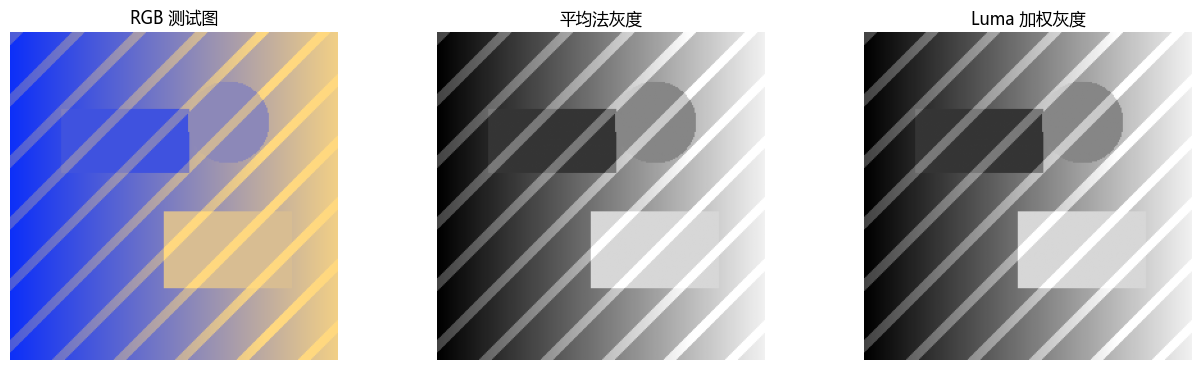

In [3]:
# ---------- 实验 2：三种灰度化对比 ----------
def rgb2gray_avg(rgb):
    return rgb.mean(axis=-1)

def rgb2gray_luma(rgb):
    return 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]

# 构造彩色测试图（三块主色 + 平滑过渡）
h, w = img.shape
rgb = np.stack([img,
                np.clip(img * 0.7 + 0.15, 0, 1),
                np.clip(1 - img * 0.5, 0, 1)], axis=-1)
g_avg = rgb2gray_avg(rgb)
g_luma = rgb2gray_luma(rgb)
diff = np.abs(g_avg - g_luma)
print('平均法 vs Luma 最大灰度差: %.3f (约 %d 个灰度级)' % (diff.max(), round(diff.max() * 255)))
show_h([rgb, g_avg, g_luma], ['RGB 测试图', '平均法灰度', 'Luma 加权灰度'], figsize=(13, 3.8))


## 4. RGB ↔ HSV：色调 / 饱和度 / 明度

HSV（Hue 色调 / Saturation 饱和度 / Value 明度）把「颜色」从「RGB 管子亮度」里解耦出来：

- **H 色调**：色环角度 $[0,360)$，红=0 绿=120 蓝=240
- **S 饱和度**：$[0,1]$，0=灰，1=纯色
- **V 明度**：$[0,1]$，通道最大值

公式（H 的六段分段）：

$$C = V \cdot S, \qquad H' = \frac{H}{60}, \qquad X = C(1 - |H' \\bmod 2 - 1|), \qquad m = V - C$$

按 $H'$ 所在扇区取 $(R',G',B')$，最后 $(R,G,B)=(R'+m, G'+m, B'+m)$。

**为什么 CV 常用 HSV**：颜色阈值（如绿色车牌、肤色检测）在 HSV 里是「一段 H 区间」，比在 RGB 里切长方体稳得多。


RGB->HSV->RGB 最大往返误差: 1.79e-07
H 通道与 matplotlib 最大差: 5.96e-08（归一化后）  S/V 最大差: 0.00e+00


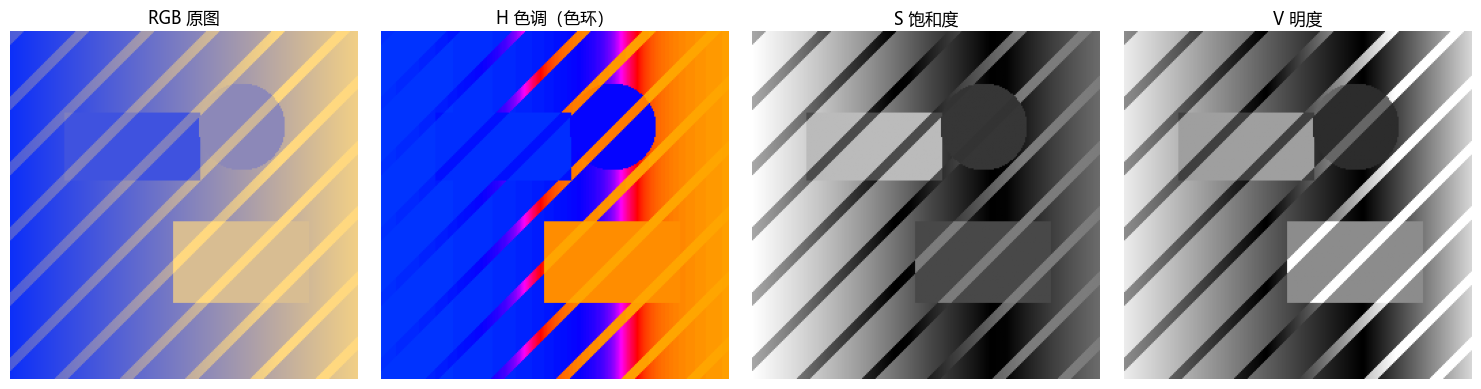

In [4]:
# ---------- 实验 3：手写 RGB<->HSV 往返 + 与 matplotlib 对照 ----------
def rgb2hsv(rgb):
    r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    mx = np.max(rgb, axis=-1); mn = np.min(rgb, axis=-1)
    d = mx - mn
    h = np.zeros_like(mx)
    safe = np.where(d > 0, d, 1.0)
    h = np.where((d > 0) & (mx == r) & (g >= b), 60 * (g - b) / safe, h)
    h = np.where((d > 0) & (mx == r) & (g < b), 60 * (g - b) / safe + 360, h)
    h = np.where((d > 0) & (mx == g), 60 * (b - r) / safe + 120, h)
    h = np.where((d > 0) & (mx == b), 60 * (r - g) / safe + 240, h)
    s = np.where(mx > 0, d / np.maximum(mx, 1e-12), 0.0)
    v = mx
    return np.stack([h, s, v], axis=-1)

def hsv2rgb(hsv):
    h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    c = v * s                                    # 色度
    hh = h / 60.0
    x = c * (1 - np.abs(hh % 2 - 1))
    m = v - c
    r0 = np.select([hh < 1, hh < 2, hh < 3, hh < 4, hh < 5, hh < 6], [c, x, 0, 0, x, c])
    g0 = np.select([hh < 1, hh < 2, hh < 3, hh < 4, hh < 5, hh < 6], [x, c, c, x, 0, 0])
    b0 = np.select([hh < 1, hh < 2, hh < 3, hh < 4, hh < 5, hh < 6], [0, 0, x, c, c, x])
    return np.stack([r0 + m, g0 + m, b0 + m], axis=-1)

hsv = rgb2hsv(rgb)
back = hsv2rgb(hsv)
err = np.abs(back - rgb).max()
print('RGB->HSV->RGB 最大往返误差: %.2e' % err)
assert err < 1e-6, '往返误差应接近 0（浮点）'

# 与 matplotlib.colors.rgb_to_hsv 对照（注意：mpl 的 H 是 0~1 的分数，需乘 360）
import matplotlib.colors as mcolors
mpl_hsv = mcolors.rgb_to_hsv(rgb)
err_h = np.abs(rgb2hsv(rgb)[..., 0] / 360.0 - mpl_hsv[..., 0]).max()
err_sv = np.abs(rgb2hsv(rgb)[..., 1:] - mpl_hsv[..., 1:]).max()
print('H 通道与 matplotlib 最大差: %.2e（归一化后）  S/V 最大差: %.2e' % (err_h, err_sv))
assert err_h < 1e-3 and err_sv < 1e-3

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
axes[0].imshow(rgb); axes[0].set_title('RGB 原图'); axes[0].axis('off')
axes[1].imshow(hsv[..., 0], cmap='hsv'); axes[1].set_title('H 色调（色环）'); axes[1].axis('off')
axes[2].imshow(hsv[..., 1], cmap='gray'); axes[2].set_title('S 饱和度'); axes[2].axis('off')
axes[3].imshow(hsv[..., 2], cmap='gray'); axes[3].set_title('V 明度'); axes[3].axis('off')
plt.tight_layout(); plt.savefig('images/cv00_hsv.png', dpi=110, bbox_inches='tight'); plt.show()


## 5. 直方图：灰度分布画像

灰度直方图 $h(k)$ = 灰度级 $k$ 出现的像素数。**直方图 = 一维信息**，丢失空间位置，
但能一眼看出：图像偏暗（直方图靠左）、偏亮（靠右）、低对比（集中）、双峰（可分前后景）。

> 🎨 **类比**：直方图是整张图的「灰度人口普查表」，均衡化就是在做「人口重新分配」——把挤在一起的灰度拉开。


手写循环 vs np.bincount 总和一致: True | 最大单点差: 0


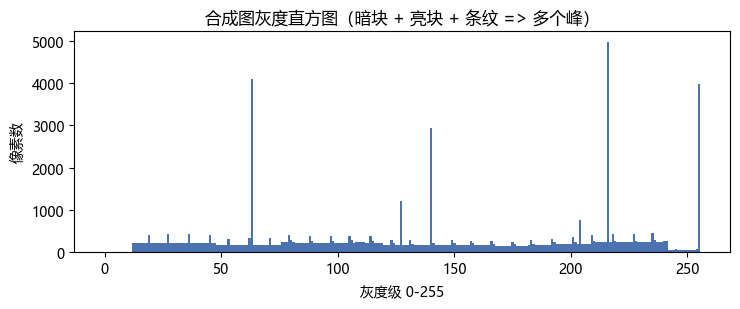

灰度级数: 244  最暗 5% 分位: 27  最亮 5% 分位: 255


In [5]:
# ---------- 实验 4：手写直方图统计（并对照 np.bincount） ----------
g8 = (img * 255).astype(np.int64)
hist_manual = np.zeros(256, dtype=np.int64)
for p in g8.ravel():
    hist_manual[p] += 1
hist_bincount = np.bincount(g8.ravel(), minlength=256)
print('手写循环 vs np.bincount 总和一致:', hist_manual.sum() == hist_bincount.sum(),
      '| 最大单点差:', int(np.abs(hist_manual - hist_bincount).max()))

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.bar(np.arange(256), hist_bincount, width=1.0, color='#4C72B0')
ax.set_xlabel('灰度级 0-255'); ax.set_ylabel('像素数')
ax.set_title('合成图灰度直方图（暗块 + 亮块 + 条纹 => 多个峰）')
plt.tight_layout(); plt.savefig('images/cv00_hist.png', dpi=110, bbox_inches='tight'); plt.show()
print('灰度级数:', np.unique(g8).size, ' 最暗 5%% 分位: %.0f  最亮 5%% 分位: %.0f' %
      (np.percentile(g8, 5), np.percentile(g8, 95)))


## 6. 直方图均衡化：CDF 映射的推导

对比度低的图灰度挤在一段，均衡化把分布**拉平**。推导两步：

1. **累计分布** $\\text{cdf}(k) = \\frac{1}{N}\\sum_{i=0}^{k} h(i)$（$N$ 为像素总数）
2. **映射** $T(k) = \\lfloor (L-1) \\cdot \\text{cdf}(k) \\rfloor$，$L=256$

为什么拉平=增强对比？灰度间隔被放大（低密度区被压缩、高密度区被拉开），
视觉上「阴影被提亮、细节更清晰」。注意：

- $T$ 是**单调不减**的（cdf 不减），保证不产生灰度反转
- 均值不变（cdf 覆盖全范围），比简单线性拉伸更自适应
- 缺点：放大噪声（尤其平坦暗区）；可用 **CLAHE**（分块 + 限幅）缓解


映射单调不减: True
灰度级数: 原图 244 -> 均衡后 185（越接近 256 分布越均匀）


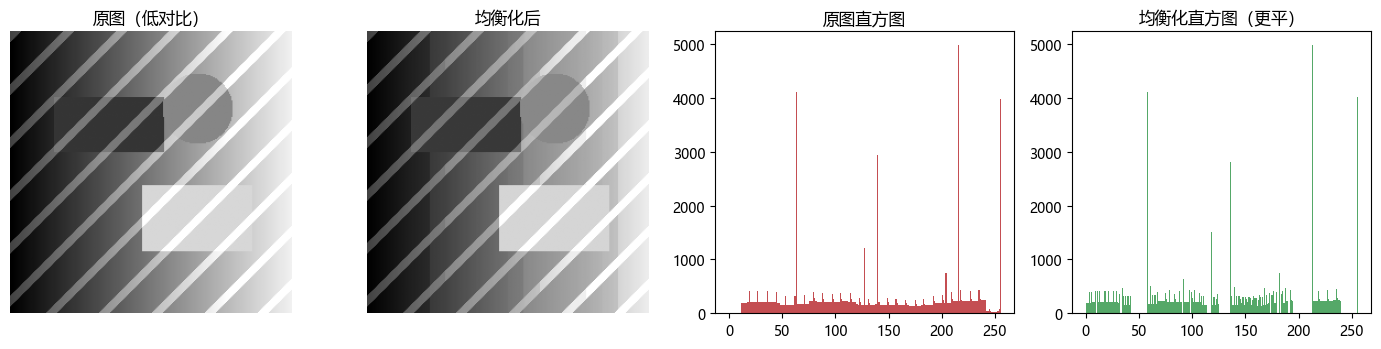

结论：原本挤在一起的低灰度被摊开到整个 0-255 区间 -> 对比度提升


In [6]:
# ---------- 实验 5：直方图均衡化 + 前后对比 ----------
def hist_equalize(g):
    g8 = np.round(g * 255).astype(np.int64)
    h = np.bincount(g8.ravel(), minlength=256).astype(np.float64)
    cdf = np.cumsum(h) / h.sum()                 # 归一化累积分布
    mapping = np.round(255 * cdf).astype(np.int64)
    return (mapping[g8] / 255.0).reshape(g.shape), mapping

eq, mapping = hist_equalize(img)
print('映射单调不减:', bool(np.all(np.diff(mapping) >= 0)))
print('灰度级数: 原图 %d -> 均衡后 %d（越接近 256 分布越均匀）' %
      (np.unique((img * 255).astype(np.int64)).size, np.unique(mapping[(img * 255).astype(np.int64)]).size))

h0 = np.bincount((img * 255).astype(np.int64).ravel(), minlength=256)
h1 = np.bincount((eq * 255).astype(np.int64).ravel(), minlength=256)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('原图（低对比）'); axes[0].axis('off')
axes[1].imshow(eq, cmap='gray'); axes[1].set_title('均衡化后'); axes[1].axis('off')
axes[2].bar(np.arange(256), h0, width=1.0, color='#C44E52'); axes[2].set_title('原图直方图')
axes[3].bar(np.arange(256), h1, width=1.0, color='#55A868'); axes[3].set_title('均衡化直方图（更平）')
plt.tight_layout(); plt.savefig('images/cv00_eq.png', dpi=110, bbox_inches='tight'); plt.show()
print('结论：原本挤在一起的低灰度被摊开到整个 0-255 区间 -> 对比度提升')


## 7. 卷积：滑动窗口加权求和

离散二维卷积（严格说是**相关**）:

$$(f * k)[i,j] = \\sum_{u=-a}^{a}\\sum_{v=-b}^{b} f[i+u,\\, j+v] \\cdot k[u,v]$$

| 概念 | 解释 |
|------|------|
| 核 kernel | 小矩阵（如 $3\\times3$），权重模式 |
| 边界处理 | zero 填充 / clamp（edge）/ mirror / wrap |
| valid / same / full | 输出 $H{-}k{+}1$ / $H$（补零） / $H{+}k{-}1$ |
| 相关 vs 卷积 | 相关不翻转核；数学卷积要把核旋转 180°，CNN 里习惯叫卷积实际做相关 |

> 🧩 **类比**：卷积 = 用一个「盖章模板」扫过整张图，每个位置盖一个加权平均章。
> 均值核=磨皮、高斯核=柔焦、Sobel 核=描边。


内部值: 1.0 （期望 1.0） 角点值: 0.4444 （期望 4/9=0.4444）
手写循环 vs 向量化（sliding_window_view + einsum）结果一致 ✓


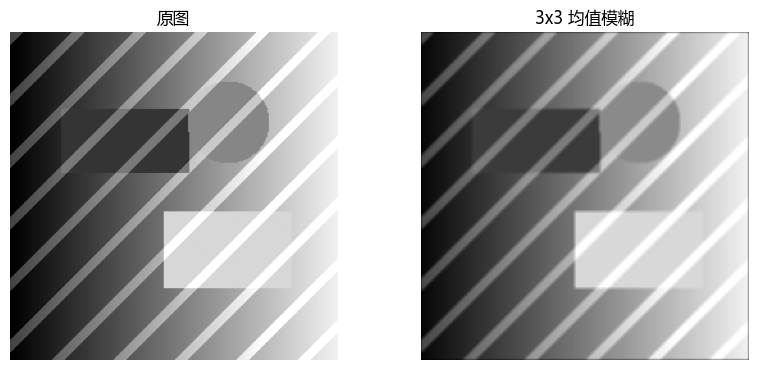

In [7]:
# ---------- 实验 6：手写二维卷积（零填充，same） ----------
def conv2d(x, k, mode='zero'):
    H, W = x.shape
    kh, kw = k.shape
    ph, pw = kh // 2, kw // 2
    if mode == 'zero':
        xp = np.zeros((H + 2 * ph, W + 2 * pw))
        xp[ph:ph + H, pw:pw + W] = x
    elif mode == 'edge':
        xp = np.pad(x, ((ph, ph), (pw, pw)), mode='edge')
    out = np.zeros_like(x)
    for i in range(H):
        for j in range(W):
            out[i, j] = np.sum(xp[i:i + kh, j:j + kw] * k)
    return out

# 数值核对：全 1 图 + 均值核，内部应为 1.0，角点应为 4/9（零填充只盖到 4 个 1）
ones5 = np.ones((5, 5))
mean3 = np.ones((3, 3)) / 9.0
out = conv2d(ones5, mean3)
print('内部值:', out[2, 2], '（期望 1.0） 角点值:', round(out[0, 0], 4), '（期望 4/9=%.4f）' % (4 / 9))
assert np.isclose(out[2, 2], 1.0) and np.isclose(out[0, 0], 4 / 9)

# 与向量化（逐像素 gather）对照，确认手写循环没错
def conv2d_vec(x, k, mode='zero'):
    H, W = x.shape
    kh, kw = k.shape
    ph, pw = kh // 2, kw // 2
    if mode == 'zero':
        xp = np.zeros((H + 2 * ph, W + 2 * pw))
        xp[ph:ph + H, pw:pw + W] = x
    elif mode == 'edge':
        xp = np.pad(x, ((ph, ph), (pw, pw)), mode='edge')
    cols = np.lib.stride_tricks.sliding_window_view(xp, (kh, kw))
    return np.einsum('ijkl,kl->ij', cols, k)

rnd = rng.random((64, 64))
assert np.allclose(conv2d(rnd, mean3), conv2d_vec(rnd, mean3))
print('手写循环 vs 向量化（sliding_window_view + einsum）结果一致 ✓')
blur3 = conv2d(img, mean3)
show_h([img, blur3], ['原图', '3x3 均值模糊'], figsize=(8.4, 3.8))


## 8. 高斯模糊：核构造与 sigma 直觉

高斯核由二维高斯函数采样：

$$G(x,y) = \\frac{1}{2\\pi\\sigma^2} e^{-\\frac{x^2+y^2}{2\\sigma^2}}$$

- $\sigma$ 越大 → 核越宽、越平 → **越模糊**（保留低频、滤掉高频）
- 核尺寸一般取 $6\\sigma+1$（覆盖 99.7% 能量）
- **可分离性**：$G = g(x) \\otimes g(y)$，两个一维卷积代替一个二维，复杂度 $O(k)$ → $O(2k)$
- 用途：降噪（Canny 第一步）、图像金字塔、特征尺度空间（SIFT 的基础）


3x3 sigma=0.8 高斯核:
 [[0.0571 0.1248 0.0571]
 [0.1248 0.2725 0.1248]
 [0.0571 0.1248 0.0571]]
核元素和（应为 1，保证亮度不变）: 1.0


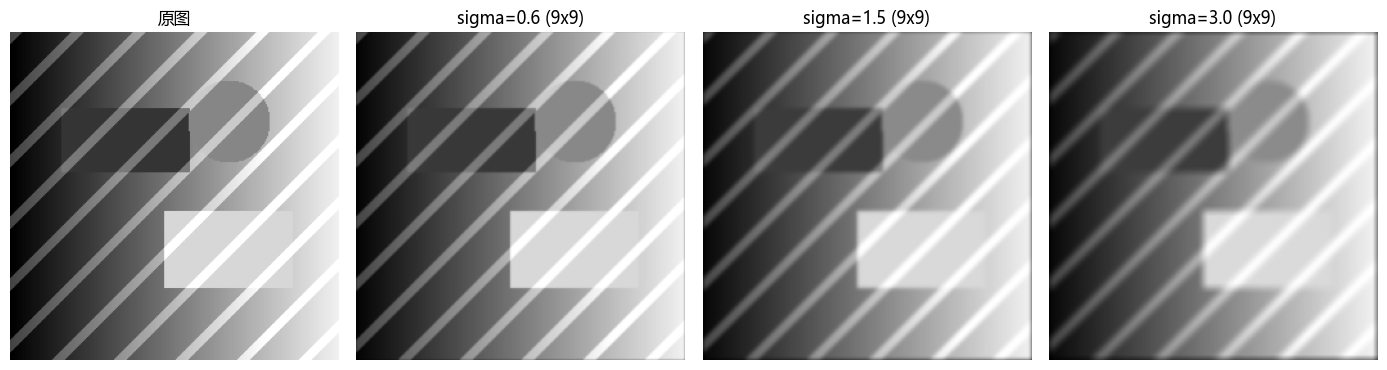

sigma=3 后图像方差: 0.0813 -> 0.0753（高频被滤掉，方差下降）


In [8]:
# ---------- 实验 7：高斯核手写 + sigma 扫描 ----------
def gauss_kernel(size, sigma):
    ax = np.arange(-(size // 2), size // 2 + 1, dtype=float)
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    return k / k.sum()

print('3x3 sigma=0.8 高斯核:\n', np.round(gauss_kernel(3, 0.8), 4))
print('核元素和（应为 1，保证亮度不变）:', round(gauss_kernel(3, 0.8).sum(), 8))

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('原图'); axes[0].axis('off')
for i, s in enumerate([0.6, 1.5, 3.0]):
    k = gauss_kernel(9, s)
    axes[i + 1].imshow(conv2d(img, k), cmap='gray')
    axes[i + 1].set_title('sigma=%.1f (9x9)' % s); axes[i + 1].axis('off')
plt.tight_layout(); plt.savefig('images/cv00_gauss.png', dpi=110, bbox_inches='tight'); plt.show()
print('sigma=3 后图像方差: %.4f -> %.4f（高频被滤掉，方差下降）' % (img.var(), conv2d(img, gauss_kernel(9, 3.0)).var()))


## 9. 中值滤波：椒盐噪声的克星

- **均值/高斯**：对**高斯噪声**最优（线性滤波），但对**椒盐噪声**会被极端值拉偏
- **中值**：取窗口内中位数，**对椒盐噪声极其鲁棒**（极端值进不了中位数），还能保边缘（非线性）

| 噪声类型 | 均值/高斯 | 中值滤波 |
|----------|-----------|----------|
| 高斯噪声 | ✅ 优 | 可接受 |
| 椒盐噪声 | ❌ 出现胡椒斑 | ✅ 干净 |
| 边缘保持 | ❌ 边缘糊 | ✅ 好 |
| 计算 | 快（线性） | 略慢（排序） |


去噪 MSE（越小越好）  高斯滤波: 0.0036   中值滤波: 0.0001


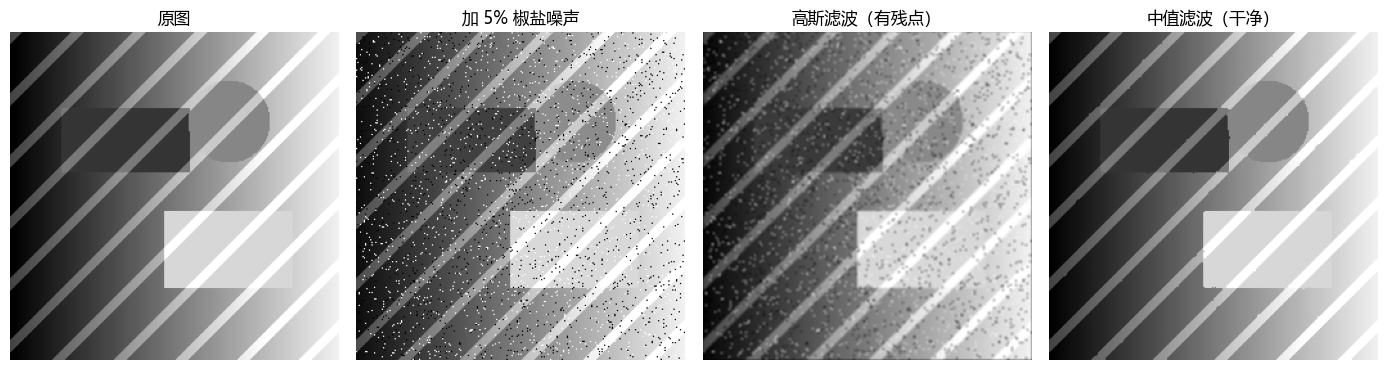

In [9]:
# ---------- 实验 8：椒盐噪声去噪：均值 vs 中值 ----------
noisy = img.copy()
mask = rng.random(img.shape) < 0.05
noisy[mask] = rng.choice([0.0, 1.0], size=int(mask.sum()))   # 5% 椒盐

def median_filter(x, ksize=3):
    pad = ksize // 2
    xp = np.pad(x, pad, mode='edge')
    H, W = x.shape
    out = np.zeros_like(x)
    for i in range(H):
        for j in range(W):
            out[i, j] = np.median(xp[i:i + ksize, j:j + ksize])
    return out

g_mean = conv2d(noisy, gauss_kernel(3, 1.0))
g_med = median_filter(noisy)
mse = lambda a, b: float(np.mean((a - b) ** 2))
print('去噪 MSE（越小越好）  高斯滤波: %.4f   中值滤波: %.4f' % (mse(g_mean, img), mse(g_med, img)))
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('原图'); axes[0].axis('off')
axes[1].imshow(noisy, cmap='gray'); axes[1].set_title('加 5% 椒盐噪声'); axes[1].axis('off')
axes[2].imshow(g_mean, cmap='gray'); axes[2].set_title('高斯滤波（有残点）'); axes[2].axis('off')
axes[3].imshow(g_med, cmap='gray'); axes[3].set_title('中值滤波（干净）'); axes[3].axis('off')
plt.tight_layout(); plt.savefig('images/cv00_median.png', dpi=110, bbox_inches='tight'); plt.show()


## 10. 锐化：Laplacian 与 Unsharp Mask

- **Laplacian 核**（二阶导数近似）：$\\nabla^2 f = f_{xx} + f_{yy}$，核 `[[0,-1,0],[-1,4,-1],[0,-1,0]]`，响应大处 = 边缘
- **锐化公式**：$g = f - \\lambda \\nabla^2 f$（在边缘处减去「负谷值」→ 加强对比）
- **Unsharp Mask**：$g = f + \\lambda(f - \\text{blur})$，即「原图 + 高频细节 × 增益」

> 🧩 **类比**：锐化 = 给照片描一层更黑的边线，细节「立起来」；过度锐化会出现白边（halo 效应）。


Laplacian 最大绝对响应（边缘强度指示）: 1.8965


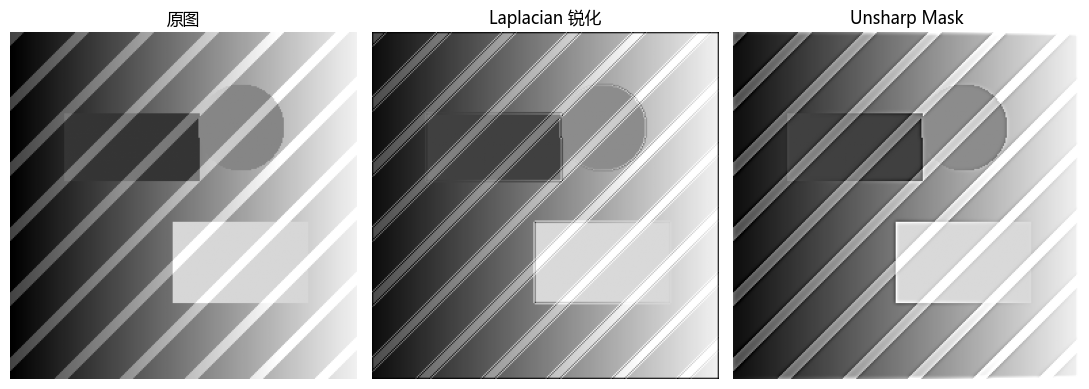

In [10]:
# ---------- 实验 9：Laplacian 与 Unsharp Mask 锐化 ----------
lap = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]])
lap_img = conv2d(img, lap)
sharp = np.clip(img - 0.8 * lap_img, 0, 1)            # g = f - λ·∇²f
blur = conv2d(img, gauss_kernel(7, 1.5))
unsharp = np.clip(img + 1.0 * (img - blur), 0, 1)     # unsharp mask

print('Laplacian 最大绝对响应（边缘强度指示）:', round(np.abs(lap_img).max(), 4))
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('原图'); axes[0].axis('off')
axes[1].imshow(sharp, cmap='gray'); axes[1].set_title('Laplacian 锐化'); axes[1].axis('off')
axes[2].imshow(unsharp, cmap='gray'); axes[2].set_title('Unsharp Mask'); axes[2].axis('off')
plt.tight_layout(); plt.savefig('images/cv00_sharp.png', dpi=110, bbox_inches='tight'); plt.show()


## 11. 阈值分割与 Otsu：最大化类间方差

全局二值化选阈值 $t$，前后景两类 $\\omega_0,\\omega_1$（概率）、均值 $\\mu_0,\\mu_1$：

$$\\sigma_B^2(t) = \\omega_0(t)\\,\\omega_1(t)\\,\\big(\\mu_0(t) - \\mu_1(t)\\big)^2$$

Otsu 遍历所有 $t$ 取 $\\arg\\max \\sigma_B^2$。

- 只需直方图，$O(L)$ 扫描，$L=256$，**无需调参**
- 假设直方图**双峰**（前后景可分离）；光照不均/多峰时失效 → 自适应阈值 / Sauvola
- 面试常考：推导类间方差式 + 说明为什么要 `w0*w1`（两峰都大时隔得远才有意义）


Otsu 阈值 = 109 （两峰中心 60/160，期望落中间 ≈110）


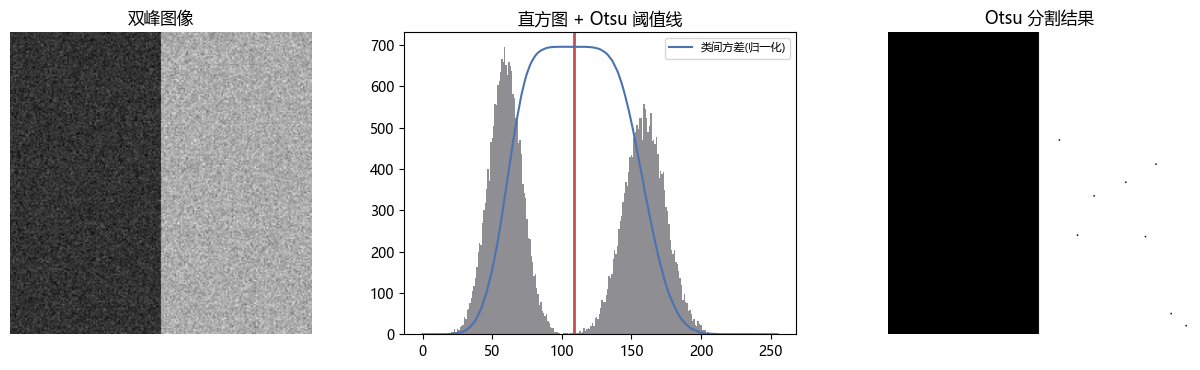

In [11]:
# ---------- 实验 10：手写 Otsu + 双峰验证 ----------
# 双峰图像：左半暗高斯(60)，右半亮高斯(160)
yy, xx = np.mgrid[0:200, 0:200]
bi = np.where(xx < 100, rng.normal(60, 12, (200, 200)), rng.normal(160, 15, (200, 200)))
bi = np.clip(bi, 0, 255)

def otsu(g8):
    h = np.bincount(g8.ravel(), minlength=256).astype(np.float64)
    total = h.sum()
    w0 = np.cumsum(h)
    w1 = total - w0
    mu = np.cumsum(h * np.arange(256))
    m0 = mu / np.maximum(w0, 1e-9)
    m1 = (mu[-1] - mu) / np.maximum(w1, 1e-9)
    sigma_b = w0 * w1 * (m0 - m1) ** 2
    return int(np.argmax(sigma_b)), sigma_b

t, sigma_curve = otsu(bi.astype(np.int64))
print('Otsu 阈值 =', t, '（两峰中心 60/160，期望落中间 ≈110）')
seg = bi > t
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].imshow(bi, cmap='gray'); axes[0].set_title('双峰图像'); axes[0].axis('off')
axes[1].bar(np.arange(256), np.bincount(bi.astype(np.int64).ravel(), minlength=256), width=1.0, color='#8E8E93')
axes[1].axvline(t, color='#C44E52', lw=2); axes[1].set_title('直方图 + Otsu 阈值线')
axes[1].plot(np.arange(256), sigma_curve / sigma_curve.max() * np.bincount(bi.astype(np.int64).ravel(), minlength=256).max(),
             color='#4C72B0', lw=1.5, label='类间方差(归一化)')
axes[1].legend(fontsize=8)
axes[2].imshow(seg, cmap='gray'); axes[2].set_title('Otsu 分割结果'); axes[2].axis('off')
plt.tight_layout(); plt.savefig('images/cv00_otsu.png', dpi=110, bbox_inches='tight'); plt.show()


## 12. 几何变换：缩放（最近邻 vs 双线性）与旋转

- **最近邻**：目标像素取最近的源像素 → 快但**锯齿**
- **双线性**：取 2×2 邻域做两次线性插值 → 平滑，性价比之王

$$f(x,y) \\approx (1{-}f_y)\\big[(1{-}f_x)f(x_0,y_0) + f_x\\,f(x_0{+}1,y_0)\\big] + f_y\\big[(1{-}f_x)f(x_0,y_0{+}1) + f_x\\,f(x_0{+}1,y_0{+}1)\\big]$$

- **旋转**：用**逆映射**（目标→源）避免空洞；组合变换用齐次坐标矩阵乘法
- 更高阶：双三次（bicubic，-0.5 系数）、LANCZOS（放大更锐利）

> ⚠️ 面试手撕高频题：**手写双线性插值**（公式 + 边界处理）。


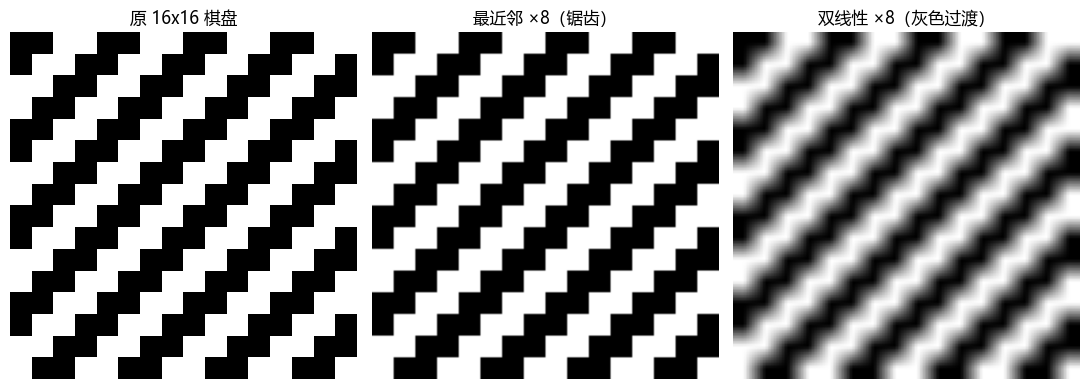

双线性放大后棋盘中线灰度序列（片段）: [0.    0.035 0.59  0.965 0.41 ] -> 出现 0.5 中间灰，最近邻则只有 0/1


In [12]:
# ---------- 实验 11：最近邻 vs 双线性缩放 ----------
chess = ((np.indices((16, 16)).sum(axis=0) // 2) % 2).astype(float)   # 2x2 棋盘

def resize_nn(x, scale):
    H, W = x.shape
    H2, W2 = int(H * scale), int(W * scale)
    ys = np.minimum((np.arange(H2) * H // H2), H - 1)
    xs = np.minimum((np.arange(W2) * W // W2), W - 1)
    return x[np.ix_(ys, xs)]

def resize_bilinear(x, scale):
    H, W = x.shape
    H2, W2 = int(H * scale), int(W * scale)
    sy = np.clip((np.arange(H2) + 0.5) * (H / H2) - 0.5, 0, H - 1)   # 对齐中心并夹到 [0, H-1]
    sx = np.clip((np.arange(W2) + 0.5) * (W / W2) - 0.5, 0, W - 1)
    y0 = np.floor(sy).astype(int); y1 = np.minimum(y0 + 1, H - 1)
    x0 = np.floor(sx).astype(int); x1 = np.minimum(x0 + 1, W - 1)
    fy = (sy - y0)[:, None]; fx = (sx - x0)[None, :]
    top = x[np.ix_(y0, x0)] * (1 - fx) + x[np.ix_(y0, x1)] * fx
    bot = x[np.ix_(y1, x0)] * (1 - fx) + x[np.ix_(y1, x1)] * fx
    return top * (1 - fy) + bot * fy

up_nn = resize_nn(chess, 8)
up_bi = resize_bilinear(chess, 8)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
axes[0].imshow(chess, cmap='gray'); axes[0].set_title('原 16x16 棋盘'); axes[0].axis('off')
axes[1].imshow(up_nn, cmap='gray'); axes[1].set_title('最近邻 ×8（锯齿）'); axes[1].axis('off')
axes[2].imshow(up_bi, cmap='gray'); axes[2].set_title('双线性 ×8（灰色过渡）'); axes[2].axis('off')
plt.tight_layout(); plt.savefig('images/cv00_resize.png', dpi=110, bbox_inches='tight'); plt.show()

# 双线性"不爱走 Z 字"验证：棋盘中间应有 [0, 0.5, 1] 灰度过渡
mid = up_bi[8 * 8 + 4, :]
print('双线性放大后棋盘中线灰度序列（片段）:', np.round(mid[::8][:5], 3),
      '-> 出现 0.5 中间灰，最近邻则只有 0/1')


旋转 30° 输出尺寸: (363, 363) （正方形画布容纳旋转后的图）


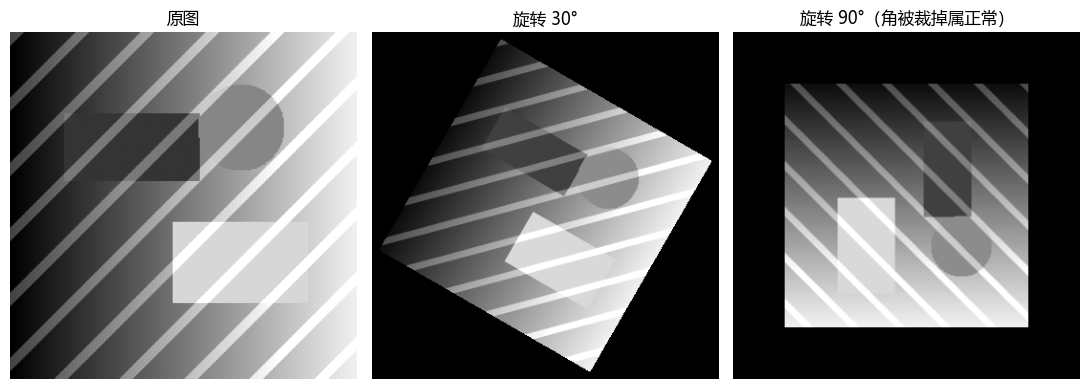

In [13]:
# ---------- 实验 12：旋转（逆映射 + 双线性采样，越界填 0） ----------
def rotate_bilinear(x, angle):
    H, W = x.shape
    theta = np.deg2rad(angle)
    c, s = np.cos(theta), np.sin(theta)
    H2 = W2 = int(np.ceil(np.hypot(H, W)))
    cy, cx = (H2 - 1) / 2, (W2 - 1) / 2
    ys, xs = np.mgrid[0:H2, 0:W2].astype(float)
    ys = ys - cy; xs = xs - cx                       # 坐标系移到中心
    y0 = c * ys - s * xs                             # 逆旋转（目标 -> 源）
    x0 = s * ys + c * xs
    y0 = y0 + (H - 1) / 2; x0 = x0 + (W - 1) / 2
    inside = (y0 >= 0) & (y0 <= H - 1) & (x0 >= 0) & (x0 <= W - 1)
    y0c = np.clip(y0, 0, H - 1); x0c = np.clip(x0, 0, W - 1)
    yy = np.clip(np.floor(y0c).astype(int), 0, H - 2)
    xx = np.clip(np.floor(x0c).astype(int), 0, W - 2)
    fy = y0c - yy; fx = x0c - xx
    out = (x[yy, xx] * (1 - fx) + x[yy, xx + 1] * fx) * (1 - fy) + \
          (x[yy + 1, xx] * (1 - fx) + x[yy + 1, xx + 1] * fx) * fy
    return np.where(inside, out, 0.0)

rot30 = rotate_bilinear(img, 30)
rot90 = rotate_bilinear(img, 90)
print('旋转 30° 输出尺寸:', rot30.shape, '（正方形画布容纳旋转后的图）')
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('原图'); axes[0].axis('off')
axes[1].imshow(rot30, cmap='gray'); axes[1].set_title('旋转 30°'); axes[1].axis('off')
axes[2].imshow(rot90, cmap='gray'); axes[2].set_title('旋转 90°（角被裁掉属正常）'); axes[2].axis('off')
plt.tight_layout(); plt.savefig('images/cv00_rotate.png', dpi=110, bbox_inches='tight'); plt.show()


## 13. 工程向：数据增强（CV 特有）

| 增强 | 做法 | 面试点 |
|------|------|--------|
| 几何 | 翻转/旋转/裁剪/缩放/仿射 | 测试时不能翻转（除非 TTA） |
| 颜色 | 亮度/对比度/色相抖动、灰度化 | 与真实分布同分布才有效 |
| 噪声 | 高斯/椒盐噪声、模糊 | 提高鲁棒性 |
| 高级 | Mixup / Cutout / CutMix / RandAugment | 缓解过拟合、少样本 |

> 面试常问「为什么 CV 数据增强比 NLP 更常用」：图像是连续信号、语义在局部邻域内保持不变性好，
> 翻转/裁剪不改变内容；文本离散且顺序敏感，乱序即毁语义。


## 14. 易错点与数字敏感度（背诵）

**易错点**
1. dtype 溢出：uint8 加减回绕 → 先 float 后 clip
2. 卷积边界：不处理边界输出尺寸会变小；zero 填充 vs edge 填充结果不同
3. 核要归一化（高斯/均值核和为 1），否则图像整体变亮/变暗
4. 灰度化权重顺序 `0.299 0.587 0.114` 记成 GRB 顺序
5. Otsu 只适合双峰；直方图均衡化会放大暗区噪声

**数字敏感度**
- 1080p = 1920×1080 ≈ 200 万像素；4K ≈ 830 万
- 1 张 224×224×3 的 uint8 图在内存 = 224×224×3 = 150KB（≈0.15MB）
- 灰度化权重：0.299 / 0.587 / 0.114（和为 1）
- Otsu 扫描次数 O(256)；直方图均衡化映射单调不减


## 15. 面试速答（30 秒背诵版）

- **灰度化为什么加权**：人眼对绿最敏感 → 0.299R + 0.587G + 0.114B
- **直方图均衡化**：$T(k)=\\lfloor255\\cdot\\text{cdf}(k)\\rfloor$，单调不减，拉平分布提对比度；CLAHE 防噪声放大
- **高斯模糊**：$\\sigma$ 越大越糊；可分离成两次一维卷积；先查 $6\\sigma+1$ 核尺寸
- **中值 vs 均值**：椒盐噪声用中值（鲁棒、保边）；高斯噪声用均值/高斯
- **锐化**：$f - \\lambda\\nabla^2 f$ 或 unsharp mask $f+\\lambda(f-\\text{blur})$
- **Otsu**：最大化类间方差 $\\omega_0\\omega_1(\\mu_0-\\mu_1)^2$，$O(256)$ 扫描直方图
- **双线性插值**：2×2 邻域两次线性插值；旋转用逆映射避免空洞


## 16. 自测清单

- [ ] 手写灰度化（加权公式），能说出 0.299/0.587/0.114 的来源（人眼对绿敏感）
- [ ] 手写直方图均衡化（CDF 映射 + 单调性验证），说清为什么增强对比度、有什么缺点
- [ ] 手写 conv2d（same + zero padding），说清 valid/same/full 输出尺寸
- [ ] 手写高斯核生成，能口算 sigma 与核尺寸关系（6σ+1）、可分离性好处
- [ ] 手写 Otsu（类间方差公式 + argmax），说清适用前提（双峰）与失效场景
- [ ] 手写双线性插值（公式 + 边界处理），说出最近邻/双线性/双三次的区别
- [ ] 口算：112×112 特征图 × 32 通道 uint8 占用多少字节（112×112×32 = 401KB）
- [ ] 说清 uint8 溢出回绕（255+30=29）与正确写法（float+clip）

> 💡 本章验收指路：`09-计算机视觉/README.md` 验收清单「图像基础/滤波/阈值/插值」打勾；
> 下一篇 `01-边缘检测与特征提取` 在 conv2d 之上加梯度与 Canny。
